# NYC 311 Data Overview

## Purpose

This notebook provides a structural overview of the live NYC 311
service-request API used for the Urban Operations Intelligence Platform.

It examines dataset dimensions, selected columns, initial data types, date
coverage, agencies, complaint categories, descriptors, statuses, boroughs,
intake channels, location types, and complaint volume over time.

This notebook does not perform detailed cleaning, target creation, final
feature selection, data splitting, modelling, or production ingestion.

## API analysis boundary

Loading the complete live JSON dataset into memory is not appropriate for an
overview notebook. This notebook therefore uses:

- full-dataset server-side API aggregations for counts and categorical or
  temporal summaries;
- a deterministic, bounded sample of a fixed number of records per creation
  year for row-level previews, pandas-inferred types, distinct-value
  inspection, memory usage, and high-level completeness.

Every sample-derived result is labelled. The raw API values are preserved,
and the sample dataframe is never cleaned or overwritten.

## 1. Imports and display configuration

Only standard-library HTTP utilities, pandas, matplotlib, and notebook display
helpers are used. No packages are installed by this notebook.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlencode
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

## 2. Project paths and API configuration

All output paths are resolved from the repository root through the shared
path utility. The established per-notebook report directories are created
idempotently so the notebook can be rerun without manual setup.

In [2]:
PROJECT_ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "urban_ops").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from urban_ops.data.api_client import fetch_json_url
from urban_ops.data.nyc_311_config import (
    API_ENDPOINT,
    API_MAX_ATTEMPTS,
    API_TIMEOUT_SECONDS,
    GROUP_RESULT_LIMIT,
    SAMPLE_ROWS_PER_YEAR,
    SELECTED_COLUMNS,
    SOURCE_QUERY,
)
from urban_ops.utils.paths import (
    ensure_report_directories,
    notebook_report_paths,
)

REPORT_DIR, REPORT_TABLES_DIR, REPORT_FIGURES_DIR = notebook_report_paths(
    "01_data_overview"
)
ensure_report_directories("01_data_overview")

PROJECT_ROOT, API_ENDPOINT, len(SELECTED_COLUMNS)


(PosixPath('/Users/mohammadmubashir/VCode/urban-operations-intelligence-platform'),
 'https://data.cityofnewyork.us/resource/erm2-nwe9.json',
 44)

## 3. Read-only API access

The helper below performs read-only GET requests with an explicit timeout and
bounded retries. It validates that the endpoint returned a JSON list. This is
not a production ingestion pipeline; it is the smallest reliable boundary
needed for this notebook.

If the local Jupyter kernel cannot resolve the API hostname, the helper uses
Cloudflare's encrypted DNS-over-HTTPS service to resolve the unchanged NYC
Open Data hostname. The subsequent API connection still validates TLS against
`data.cityofnewyork.us`; it does not use a cached dataset, a CSV source, or a
hardcoded Socrata server address.

In [3]:
API_REQUEST_HEADERS = {
    "User-Agent": "urban-operations-intelligence-data-overview/1.0",
}


def fetch_api_records(soql_query: str) -> list[dict[str, object]]:
    """Return records from one SoQL query using the shared API client."""
    query_url = f"{API_ENDPOINT}?{urlencode({'$query': soql_query})}"
    payload = fetch_json_url(
        query_url,
        timeout_seconds=API_TIMEOUT_SECONDS,
        max_attempts=API_MAX_ATTEMPTS,
        headers=API_REQUEST_HEADERS,
    )
    if not isinstance(payload, list):
        raise RuntimeError("NYC Open Data returned JSON that was not a list.")
    records = [record for record in payload if isinstance(record, dict)]
    if len(records) != len(payload):
        raise RuntimeError("NYC Open Data returned a non-object row.")
    return records


def build_group_summary_query(group_columns: list[str]) -> str:
    """Build the server-side query used for a complete group summary."""
    group_expression = ", ".join(group_columns)
    return (
        f"SELECT {group_expression}, count(*) AS record_count "
        f"GROUP BY {group_expression} "
        f"ORDER BY record_count DESC LIMIT {GROUP_RESULT_LIMIT}"
    )


def fetch_group_summary(
    group_columns: list[str],
    output_names: list[str],
    total_row_count: int,
) -> pd.DataFrame:
    """Return a complete full-dataset group summary with missing labels."""
    records = fetch_api_records(build_group_summary_query(group_columns))
    if len(records) >= GROUP_RESULT_LIMIT:
        raise RuntimeError(
            f"Grouped query reached its {GROUP_RESULT_LIMIT:,}-row safety limit."
        )

    source_frame = pd.DataFrame(records)
    summary = pd.DataFrame()
    for source_name, output_name in zip(
        group_columns,
        output_names,
        strict=True,
    ):
        if source_name in source_frame:
            summary[output_name] = source_frame[source_name].fillna("<MISSING>")
        else:
            summary[output_name] = "<MISSING>"

    summary["record_count"] = pd.to_numeric(
        source_frame["record_count"],
        errors="raise",
    ).astype("int64")
    summary["record_percentage"] = (
        summary["record_count"] / total_row_count * 100
    )
    return summary


def save_horizontal_bar_chart(
    summary: pd.DataFrame,
    label_column: str,
    title: str,
    output_path: Path,
    top_n: int | None = None,
) -> None:
    """Save a readable horizontal count chart from a descending summary."""
    plot_frame = summary.head(top_n).sort_values("record_count")
    figure_height = max(4.5, min(12.0, len(plot_frame) * 0.42))
    figure, axis = plt.subplots(figsize=(11, figure_height))
    axis.barh(plot_frame[label_column].astype(str), plot_frame["record_count"])
    axis.set_title(title)
    axis.set_xlabel("Request count")
    axis.set_ylabel("")
    axis.grid(axis="x", alpha=0.25)
    figure.tight_layout()
    figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figure)


## 4. Full-dataset scope and deterministic raw sample

> **Analysis scope:** The dataset row count and creation-date bounds use a
> server-side aggregation over the complete live NYC 311 API dataset.

> **Analysis scope:** Row-level inspection uses the deterministic sample,
> not the complete dataset.

The row-level sample is deterministic and reproducible. It selects a fixed
number of early records from each year using `created_date` and `unique_key`
ordering.

It is suitable for:

- inspecting selected columns and values;
- examining example records;
- checking how pandas initially parses fields;
- creating readable previews.

It is not statistically representative of the full dataset and must not be
used to estimate:

- population-wide missingness;
- category proportions;
- complete distinct-value counts;
- production data-quality rates.

In [4]:
scope_query = (
    "SELECT count(*) AS row_count, "
    "min(created_date) AS minimum_created_date, "
    "max(created_date) AS maximum_created_date"
)
scope_record = fetch_api_records(scope_query)[0]

total_row_count = int(scope_record["row_count"])
minimum_created_date = pd.to_datetime(scope_record["minimum_created_date"])
maximum_created_date = pd.to_datetime(scope_record["maximum_created_date"])
sample_years = list(
    range(minimum_created_date.year, maximum_created_date.year + 1)
)
sample_ordering = "created_date ASC, unique_key ASC"

DATE_COLUMNS = [
    "created_date",
    "closed_date",
    "due_date",
    "resolution_action_updated_date",
]
date_select_expressions = ["count(*) AS total_rows"]
for date_column in DATE_COLUMNS:
    date_select_expressions.extend(
        [
            f"min({date_column}) AS {date_column}_minimum",
            f"max({date_column}) AS {date_column}_maximum",
            f"count({date_column}) AS {date_column}_non_null",
        ]
    )

date_query = "SELECT " + ", ".join(date_select_expressions)
year_query = (
    "SELECT date_extract_y(created_date) AS creation_year, "
    "count(*) AS record_count "
    "GROUP BY date_extract_y(created_date) "
    "ORDER BY creation_year"
)
month_query = (
    "SELECT date_trunc_ym(created_date) AS creation_month, "
    "count(*) AS record_count "
    "GROUP BY date_trunc_ym(created_date) "
    "ORDER BY creation_month"
)
group_query_columns = {
    "agency_summary": ["agency", "agency_name"],
    "complaint_type_summary": ["complaint_type"],
    "descriptor_summary": ["descriptor"],
    "complaint_type_descriptor_summary": ["complaint_type", "descriptor"],
    "status_summary": ["status"],
    "borough_summary": ["borough"],
    "channel_summary": ["open_data_channel_type"],
    "location_type_summary": ["location_type"],
}

sample_records: list[dict[str, object]] = []
for sample_year in sample_years:
    next_year = sample_year + 1
    sample_query = (
        f"{SOURCE_QUERY} "
        f"WHERE created_date >= '{sample_year}-01-01T00:00:00' "
        f"AND created_date < '{next_year}-01-01T00:00:00' "
        "ORDER BY created_date, unique_key "
        f"LIMIT {SAMPLE_ROWS_PER_YEAR}"
    )
    sample_records.extend(fetch_api_records(sample_query))

df = pd.DataFrame(sample_records).reindex(columns=SELECTED_COLUMNS)
if df.empty:
    raise RuntimeError("The NYC Open Data API returned no records for inspection.")

retrieved_at_utc = datetime.now(timezone.utc)
len(df), total_row_count, minimum_created_date, maximum_created_date

(7000,
 21922301,
 Timestamp('2020-01-01 00:00:00'),
 Timestamp('2026-07-24 01:50:58'))

### Extraction metadata

The audit metadata records the live endpoint, retrieval time, full-dataset
boundaries, selected fields, deterministic sample definition, and every
server-side aggregation used later in the notebook. JSON is the canonical
metadata artifact; the existing CSV metadata file is retained for
compatibility.

In [5]:
aggregation_queries_used = [
    {"name": "dataset_scope", "query": scope_query},
    {"name": "date_coverage", "query": date_query},
    {"name": "records_by_year", "query": year_query},
    {"name": "records_by_month", "query": month_query},
] + [
    {
        "name": query_name,
        "query": build_group_summary_query(group_columns),
    }
    for query_name, group_columns in group_query_columns.items()
]

data_overview_metadata = {
    "api_endpoint": API_ENDPOINT,
    "retrieved_at_utc": retrieved_at_utc.isoformat(),
    "query_date_lower_bound": None,
    "query_date_upper_bound": None,
    "total_row_count": total_row_count,
    "minimum_created_date": minimum_created_date.isoformat(),
    "maximum_created_date": maximum_created_date.isoformat(),
    "selected_columns": list(SELECTED_COLUMNS),
    "sample_rows_per_year": SAMPLE_ROWS_PER_YEAR,
    "sample_years": sample_years,
    "sample_row_count": len(df),
    "sample_ordering": sample_ordering,
    "aggregation_queries_used": aggregation_queries_used,
    "notebook_source_type": "live_nyc_open_data_api",
}
(REPORT_TABLES_DIR / "data_overview_metadata.json").write_text(
    json.dumps(data_overview_metadata, indent=2),
    encoding="utf-8",
)

extraction_metadata = pd.DataFrame(
    [
        {
            **{
                key: value
                for key, value in data_overview_metadata.items()
                if key
                not in {
                    "selected_columns",
                    "sample_years",
                    "aggregation_queries_used",
                }
            },
            "selected_columns": json.dumps(
                data_overview_metadata["selected_columns"]
            ),
            "sample_years": json.dumps(
                data_overview_metadata["sample_years"]
            ),
            "aggregation_queries_used": json.dumps(
                data_overview_metadata["aggregation_queries_used"]
            ),
        }
    ]
)
extraction_metadata.to_csv(
    REPORT_TABLES_DIR / "api_extraction_metadata.csv",
    index=False,
)
extraction_metadata.T

,0
api_endpoint,https://data.cityofnewyork.us/resource/erm2-nwe9.json
retrieved_at_utc,2026-07-25T08:48:57.215081+00:00
query_date_lower_bound,None
query_date_upper_bound,None
total_row_count,21922301
minimum_created_date,2020-01-01T00:00:00
maximum_created_date,2026-07-24T01:50:58
sample_rows_per_year,1000
sample_row_count,7000
sample_ordering,"created_date ASC, unique_key ASC"


## 5. Dataset dimensions and memory usage

> **Analysis scope:** Total row count and selected-column count describe the
> complete live API scope and configured API projection.

> **Analysis scope:** Memory usage is measured from the deterministic
> row-level sample, not the complete dataset.

The complete JSON dataset is not loaded. No full-dataset memory statistic is
inferred from the bounded sample.

In [6]:
sample_memory_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

dataset_overview = pd.DataFrame(
    [
        {
            "row_count": total_row_count,
            "column_count": len(SELECTED_COLUMNS),
            "row_count_analysis_scope": "full_dataset_api_aggregation",
            "sample_row_count": len(df),
            "sample_memory_usage_mb": round(sample_memory_usage_mb, 2),
            "memory_analysis_scope": "deterministic_row_sample",
        }
    ]
)
dataset_overview.to_csv(
    REPORT_TABLES_DIR / "dataset_overview.csv",
    index=False,
)
dataset_overview

,row_count,column_count,row_count_analysis_scope,sample_row_count,sample_memory_usage_mb,memory_analysis_scope
0,21922301,44,full_dataset_api_aggregation,7000,17.77,deterministic_row_sample


## 6. Dataset grain

> **Analysis scope:** This section uses the deterministic row-level sample,
> not the complete dataset.

Each returned sample row appears to represent one NYC 311 service request.
The API field **unique_key** appears to be the complaint identifier. Formal
uniqueness validation is intentionally deferred to
**02_schema_and_quality_analysis.ipynb**.

In [7]:
df.head(3)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,45285347,2020-01-01T00:00:00.000,2020-01-10T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,11229,3442 NOSTRAND AVENUE,NOSTRAND AVENUE,GRAVESEND NECK ROAD,AVENUE V,GRAVESEND NECK ROAD,AVENUE V,ADDRESS,BROOKLYN,NOSTRAND AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-10T16:38:17.000,15 BROOKLYN,46,Precinct 61,3073620008,BROOKLYN,1000400,157925,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.6001292057807,-73.94184291675883,"{'type': 'Point', 'coordinates': [-73.941842916759, 40.600129205781]}"
1,45285651,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Restaurant/Bar/Deli/Bakery,10458,2701 DECATUR AVENUE,DECATUR AVENUE,EAST 195 STREET,EAST 197 STREET,EAST 195 STREET,EAST 197 STREET,ADDRESS,BRONX,DECATUR AVENUE,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-15T16:43:53.000,07 BRONX,15,Precinct 52,2032830055,BRONX,1015012,254391,PHONE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.86486556770799,-73.88878325729915,"{'type': 'Point', 'coordinates': [-73.888783257299, 40.864865567708]}"
2,45285821,2020-01-01T00:00:00.000,2020-01-02T09:50:09.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Other (Explain Below),11203,5707 CHURCH AVENUE,CHURCH AVENUE,EAST 57 STREET,KINGS HIGHWAY,EAST 57 STREET,KINGS HIGHWAY,ADDRESS,BROOKLYN,CHURCH AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-02T09:50:00.000,17 BROOKLYN,41,Precinct 67,NaN,BROOKLYN,1005466,177022,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.65253575905768,-73.92353994017134,"{'type': 'Point', 'coordinates': [-73.923539940171, 40.652535759058]}"


## 7. Selected column inventory

> **Analysis scope:** This is the configured live API projection confirmed by
> the successful deterministic sample queries. It is not a complete metadata
> inventory of every field exposed by the endpoint.

The API uses snake_case field names. No raw dataframe columns are renamed.

In [8]:
column_inventory = pd.DataFrame(
    {
        "column_position": range(1, len(SELECTED_COLUMNS) + 1),
        "column_name": SELECTED_COLUMNS,
    }
)
column_inventory.to_csv(
    REPORT_TABLES_DIR / "column_inventory.csv",
    index=False,
)
column_inventory

,column_position,column_name
0,1,unique_key
1,2,created_date
2,3,closed_date
3,4,agency
4,5,agency_name
5,6,complaint_type
6,7,descriptor
7,8,descriptor_2
8,9,location_type
9,10,incident_zip


## 8. Initial pandas-inferred data types

> **Analysis scope:** This section uses the deterministic row-level sample,
> not the complete dataset.

Pandas infers types from observed sample values. The table therefore reports
the **initial pandas-inferred data type**, not a definitive business schema.
Identifier-like fields can appear numeric, timestamp fields can initially
appear as objects, and sparse columns can receive unstable inferred types.

In [9]:
raw_dtype_summary = pd.DataFrame(
    {
        "column_name": df.columns,
        "apparent_pandas_dtype": [str(dtype) for dtype in df.dtypes],
        "analysis_scope": "deterministic_row_sample",
    }
)
raw_dtype_summary.to_csv(
    REPORT_TABLES_DIR / "raw_dtype_summary.csv",
    index=False,
)
raw_dtype_summary

,column_name,apparent_pandas_dtype,analysis_scope
0,unique_key,str,deterministic_row_sample
1,created_date,str,deterministic_row_sample
2,closed_date,str,deterministic_row_sample
3,agency,str,deterministic_row_sample
4,agency_name,str,deterministic_row_sample
5,complaint_type,str,deterministic_row_sample
6,descriptor,str,deterministic_row_sample
7,descriptor_2,str,deterministic_row_sample
8,location_type,str,deterministic_row_sample
9,incident_zip,str,deterministic_row_sample


## 9. Preliminary logical data-type interpretation

> **Analysis scope:** Logical interpretations use the configured fields and
> deterministic sample as preliminary Day 2 evidence, not a final schema or
> feature decision.

This explanatory table distinguishes sample-observed pandas types from likely
logical business types. It does not convert the raw dataframe. Prediction-time
availability and leakage implications must be confirmed during later schema
and target-feasibility analysis.

In [10]:
logical_type_definitions = [
    (
        "unique_key",
        "identifier",
        "complaint identifier",
        "Treat as an identifier, not a quantity; validate uniqueness later.",
    ),
    (
        "created_date",
        "datetime",
        "request creation time",
        "Preliminary prediction-time assessment; confirm semantics later.",
    ),
    (
        "closed_date",
        "datetime",
        "post-creation timestamp",
        "Likely unavailable at prediction time; confirm later.",
    ),
    (
        "due_date",
        "datetime",
        "possible resolution target timestamp",
        "Potential target-construction field; validate availability and semantics.",
    ),
    (
        "agency",
        "categorical string",
        "responding agency code",
        "Operational category; validate scope and timing later.",
    ),
    (
        "agency_name",
        "categorical string",
        "responding agency name",
        "Human-readable agency label.",
    ),
    (
        "complaint_type",
        "categorical string",
        "complaint category",
        "Main request category; validate stability later.",
    ),
    (
        "descriptor",
        "categorical string",
        "complaint detail",
        "Detailed problem category; assess missingness later.",
    ),
    (
        "descriptor_2",
        "categorical string",
        "secondary complaint detail",
        "Additional API-native detail field.",
    ),
    (
        "status",
        "categorical string",
        "request state",
        "Initial and final values may differ; assess timing later.",
    ),
    (
        "incident_zip",
        "postal-code string",
        "geographic identifier",
        "Leading zeroes must remain meaningful.",
    ),
    (
        "borough",
        "categorical string",
        "geographic borough",
        "Missing and non-standard values need later review.",
    ),
    (
        "open_data_channel_type",
        "categorical string",
        "intake channel",
        "How the request entered NYC 311; confirm timing later.",
    ),
    (
        "location_type",
        "categorical string",
        "location category",
        "Operational location context.",
    ),
    (
        "latitude",
        "geographic coordinate",
        "latitude",
        "Continuous numeric coordinate when present.",
    ),
    (
        "longitude",
        "geographic coordinate",
        "longitude",
        "Continuous numeric coordinate when present.",
    ),
    (
        "resolution_description",
        "post-outcome text",
        "resolution narrative",
        "Likely unsuitable as a creation-time feature; confirm later.",
    ),
    (
        "resolution_action_updated_date",
        "datetime",
        "post-creation timestamp",
        "Likely post-creation information; validate sequence and timing later.",
    ),
]

logical_type_interpretation = pd.DataFrame(
    logical_type_definitions,
    columns=["column_name", "likely_logical_type", "business_role", "notes"],
)
logical_type_interpretation.insert(
    1,
    "pandas_inferred_type",
    logical_type_interpretation["column_name"].map(
        {column: str(dtype) for column, dtype in df.dtypes.items()}
    ),
)
logical_type_interpretation["analysis_scope"] = (
    "preliminary_interpretation_from_deterministic_row_sample"
)
logical_type_interpretation.to_csv(
    REPORT_TABLES_DIR / "logical_type_interpretation.csv",
    index=False,
)
logical_type_interpretation

,column_name,pandas_inferred_type,likely_logical_type,business_role,notes,analysis_scope
0,unique_key,str,identifier,complaint identifier,"Treat as an identifier, not a quantity; validate uniqueness later.",preliminary_interpretation_from_deterministic_row_sample
1,created_date,str,datetime,request creation time,Preliminary prediction-time assessment; confirm semantics later.,preliminary_interpretation_from_deterministic_row_sample
2,closed_date,str,datetime,post-creation timestamp,Likely unavailable at prediction time; confirm later.,preliminary_interpretation_from_deterministic_row_sample
3,due_date,float64,datetime,possible resolution target timestamp,Potential target-construction field; validate availability and semantics.,preliminary_interpretation_from_deterministic_row_sample
4,agency,str,categorical string,responding agency code,Operational category; validate scope and timing later.,preliminary_interpretation_from_deterministic_row_sample
5,agency_name,str,categorical string,responding agency name,Human-readable agency label.,preliminary_interpretation_from_deterministic_row_sample
6,complaint_type,str,categorical string,complaint category,Main request category; validate stability later.,preliminary_interpretation_from_deterministic_row_sample
7,descriptor,str,categorical string,complaint detail,Detailed problem category; assess missingness later.,preliminary_interpretation_from_deterministic_row_sample
8,descriptor_2,str,categorical string,secondary complaint detail,Additional API-native detail field.,preliminary_interpretation_from_deterministic_row_sample
9,status,str,categorical string,request state,Initial and final values may differ; assess timing later.,preliminary_interpretation_from_deterministic_row_sample


## 10. Example sample records

> **Analysis scope:** This section uses the deterministic row-level sample,
> not the complete dataset.

The first table follows the deterministic per-year API sample order. The
second uses a fixed pandas random seed only to choose examples from that
deterministic sample. Neither preview is population-representative.

In [11]:
df.head(5)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,45285347,2020-01-01T00:00:00.000,2020-01-10T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,11229,3442 NOSTRAND AVENUE,NOSTRAND AVENUE,GRAVESEND NECK ROAD,AVENUE V,GRAVESEND NECK ROAD,AVENUE V,ADDRESS,BROOKLYN,NOSTRAND AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-10T16:38:17.000,15 BROOKLYN,46,Precinct 61,3073620008,BROOKLYN,1000400,157925,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.6001292057807,-73.94184291675883,"{'type': 'Point', 'coordinates': [-73.941842916759, 40.600129205781]}"
1,45285651,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Restaurant/Bar/Deli/Bakery,10458,2701 DECATUR AVENUE,DECATUR AVENUE,EAST 195 STREET,EAST 197 STREET,EAST 195 STREET,EAST 197 STREET,ADDRESS,BRONX,DECATUR AVENUE,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-15T16:43:53.000,07 BRONX,15,Precinct 52,2032830055,BRONX,1015012,254391,PHONE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.86486556770799,-73.88878325729915,"{'type': 'Point', 'coordinates': [-73.888783257299, 40.864865567708]}"
2,45285821,2020-01-01T00:00:00.000,2020-01-02T09:50:09.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,NaN,Other (Explain Below),11203,5707 CHURCH AVENUE,CHURCH AVENUE,EAST 57 STREET,KINGS HIGHWAY,EAST 57 STREET,KINGS HIGHWAY,ADDRESS,BROOKLYN,CHURCH AVENUE,NaN,Closed,NaN,The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. ...,2020-01-02T09:50:00.000,17 BROOKLYN,41,Precinct 67,NaN,BROOKLYN,1005466,177022,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.65253575905768,-73.92353994017134,"{'type': 'Point', 'coordinates': [-73.923539940171, 40.652535759058]}"
3,45287907,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,11214,1602 SHORE PARKWAY,SHORE PARKWAY,BELT PARKWAY EXIT 5 EASTBOUND,BELT PARKWAY EB EN BAY PKWY,BELT PARKWAY EXIT 5 EASTBOUND,BELT PARKWAY EB EN BAY PKWY,ADDRESS,BROOKLYN,SHORE PARKWAY,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-15T16:51:03.000,11 BROOKLYN,43,Precinct 62,3064910050,BROOKLYN,984202,156289,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.59565343138651,-74.00017283917487,"{'type': 'Point', 'coordinates': [-74.000172839175, 40.595653431387]}"
4,45288120,2020-01-01T00:00:00.000,2020-01-02T09:51:29.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,NaN,Restaurant/Bar/Deli/Bakery,10455,748 EAST 149 STREET,EAST 149 STREET,CONCORD AVENUE,WALES AVENUE,CONCORD AVENUE,WALES AVENUE,ADDRESS,BRONX,EAST 149 STREET,NaN,Closed,NaN,The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishmen...,2020-01-02T09:51:29.000,01 BRONX,08,Precinct 40,NaN,BRONX,1009724,235487,ONLINE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.81299645614164,-73.90797324533352,"{'type': 'P

In [12]:
df.sample(n=5, random_state=42)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
6500,67349244,2026-01-01T00:59:59.000,2026-01-01T01:11:07.000,NYPD,New York City Police Department,Blocked Driveway,No Access,NaN,Street/Sidewalk,11208,902 BELMONT AVENUE,BELMONT AVENUE,LOGAN STREET,FOUNTAIN AVENUE,LOGAN STREET,FOUNTAIN AVENUE,ADDRESS,BROOKLYN,BELMONT AVENUE,NaN,Closed,NaN,The New York City Police Department responded to the complaint and their investigation determined that a violation o...,2026-01-01T01:11:09.000,05 BROOKLYN,42,Precinct 75,3042460021,BROOKLYN,1018778,184697,PHONE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.673560016165396,-73.87552574863949,"{'type': 'Point', 'coordinates': [-73.875525748639, 40.673560016165]}"
2944,52936565,2022-01-01T01:48:30.000,2022-01-01T02:10:09.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,10026,265 WEST 114 STREET,WEST 114 STREET,ADAM CLAYTON POWELL JR BOULEVARD,FREDERICK DOUGLASS BOULEVARD,ADAM CLAYTON POWELL JR BOULEVARD,FREDERICK DOUGLASS BOULEVARD,ADDRESS,NEW YORK,WEST 114 STREET,NaN,Closed,NaN,The Police Department responded to the complaint and took action to fix the condition.,2022-01-01T02:10:12.000,10 MANHATTAN,09,Precinct 28,1018300011,MANHATTAN,996213,231952,MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.80332248776049,-73.95678904346106,"{'type': 'Point', 'coordinates': [-73.956789043461, 40.80332248776]}"
2024,52933824,2022-01-01T00:05:14.000,2022-01-01T02:06:38.000,NYPD,New York City Police Department,Illegal Fireworks,N/A,NaN,Street/Sidewalk,11208,3429 ATLANTIC AVENUE,ATLANTIC AVENUE,HEMLOCK STREET,AUTUMN AVENUE,HEMLOCK STREET,AUTUMN AVENUE,ADDRESS,BROOKLYN,ATLANTIC AVENUE,NaN,Closed,NaN,The Police Department responded to the complaint and with the information available observed no evidence of the viol...,2022-01-01T02:06:46.000,05 BROOKLYN,37,Precinct 75,3041480067,BROOKLYN,1020245,187803,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.682079431383194,-73.8702205975783,"{'type': 'Point', 'coordinates': [-73.870220597578, 40.682079431383]}"
263,45288994,2020-01-01T01:01:40.000,2020-02-20T00:00:00.000,DOB,Department of Buildings,Elevator,Elevator - Multiple Devices On Property,NaN,NaN,10016,300 EAST 34 STREET,EAST 34 STREET,NaN,NaN,NaN,NaN,ADDRESS,NEW YORK,NaN,NaN,Closed,NaN,The Department of Buildings investigated this complaint and determined that no further action was necessary.,2020-02-20T00:00:00.000,06 MANHATTAN,02,Precinct 17,1009390001,MANHATTAN,990959,210603,UNKNOWN,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.744730633043375,-73.9757880681296,"{'type': 'Point', 'coordinates': [-73.97578806813, 40.744730633043]}"
4350,59887502,2024-01-01T00:40:12.000,2024-01-01T01:54:23.000,NYPD,New York City Police Department,Blocked Driveway,No Access,NaN,Street/Sidewalk,11221,119 GROVE STREET,GROVE STREET,EVERGREEN AVENUE,CENTRAL AVENUE,EVERGREEN AVENUE,CENTRAL AVENUE,ADDRESS,BROOKLYN,GROVE STREET,NaN,Closed,NaN,The Police Department responded to the complaint and with the information available observed no evidence of the viol...,2024-01-01T01:54:26.000,04 BROOKLYN,37,Precinct 83,3033140067,BROOKLYN,1006368,192039,PHONE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.69375182760021,-73.92023995858511,"{'type': 'Point', 'coordinates': [-73.920239958585, 40.6937518276]}"


## Readable sample record preview

> **Analysis scope:** This section uses the deterministic row-level sample,
> not the complete dataset.

The following preview selects a readable subset of fields only to make one
service-request record easier to read. This display choice is not final
feature selection and does not imply that remaining columns are unimportant.

All configured columns are reviewed separately through the inventory,
sample data-type summary, and sample completeness summary.

In [13]:
RECORD_PREVIEW_COLUMNS = [
    "unique_key",
    "created_date",
    "closed_date",
    "agency",
    "agency_name",
    "complaint_type",
    "descriptor",
    "status",
    "due_date",
    "borough",
    "open_data_channel_type",
]

missing_preview_columns = [
    column
    for column in RECORD_PREVIEW_COLUMNS
    if column not in df.columns
]

if missing_preview_columns:
    raise KeyError(
        "The following record preview columns are missing from the dataset: "
        f"{missing_preview_columns}"
    )

df.loc[:, RECORD_PREVIEW_COLUMNS].head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,status,due_date,borough,open_data_channel_type
0,45285347,2020-01-01T00:00:00.000,2020-01-10T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BROOKLYN,ONLINE
1,45285651,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,BRONX,PHONE
2,45285821,2020-01-01T00:00:00.000,2020-01-02T09:50:09.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,BROOKLYN,ONLINE
3,45287907,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BROOKLYN,ONLINE
4,45288120,2020-01-01T00:00:00.000,2020-01-02T09:51:29.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BRONX,ONLINE
5,45288240,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,QUEENS,ONLINE
6,45288728,2020-01-01T00:00:00.000,2020-01-02T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,BROOKLYN,ONLINE
7,45289555,2020-01-01T00:00:00.000,2020-01-02T09:39:33.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,NaN,QUEENS,ONLINE
8,45289558,2020-01-01T00:00:00.000,2020-01-15T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Closed,NaN,BROOKLYN,ONLINE
9,45282225,2020-01-01T00:01:12.000,2020-01-01T03:07:10.000,NYPD,New York City Police Department,Blocked Driveway,No Access,Closed,NaN,BROOKLYN,PHONE


## 11. Full-dataset date coverage

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

Minimum, maximum, non-null, and missing counts are computed server-side.
Detailed timestamp parsing and sequence validation are deferred to
**02_schema_and_quality_analysis.ipynb**. No source values are converted.

In [14]:
date_record = fetch_api_records(date_query)[0]
date_total_rows = int(date_record["total_rows"])

date_coverage_rows = []
for date_column in DATE_COLUMNS:
    non_null_count = int(date_record.get(f"{date_column}_non_null", 0))
    missing_count = date_total_rows - non_null_count
    date_coverage_rows.append(
        {
            "column": date_column,
            "minimum_date": date_record.get(f"{date_column}_minimum"),
            "maximum_date": date_record.get(f"{date_column}_maximum"),
            "non_null_count": non_null_count,
            "missing_count": missing_count,
            "missing_percentage": missing_count / date_total_rows * 100,
            "analysis_scope": "full_dataset_api_aggregation",
        }
    )

date_coverage = pd.DataFrame(date_coverage_rows)
date_coverage.to_csv(
    REPORT_TABLES_DIR / "date_coverage.csv",
    index=False,
)
date_coverage

,column,minimum_date,maximum_date,non_null_count,missing_count,missing_percentage,analysis_scope
0,created_date,2020-01-01T00:00:00.000,2026-07-24T01:50:58.000,21922301,0,0.000000,full_dataset_api_aggregation
1,closed_date,1899-12-31T19:00:00.000,2033-03-01T00:00:00.000,21506508,415793,1.896667,full_dataset_api_aggregation
2,due_date,2018-09-29T09:26:39.000,2026-08-22T20:02:47.000,76987,21845314,99.648819,full_dataset_api_aggregation
3,resolution_action_updated_date,2019-07-18T00:00:00.000,2026-12-14T11:50:00.000,21742539,179762,0.819996,full_dataset_api_aggregation


## 12. Requests by creation year

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

The latest year is labelled as partial when the maximum available creation
date falls before the end of that calendar year. The table behind the chart
is saved for reproducibility.

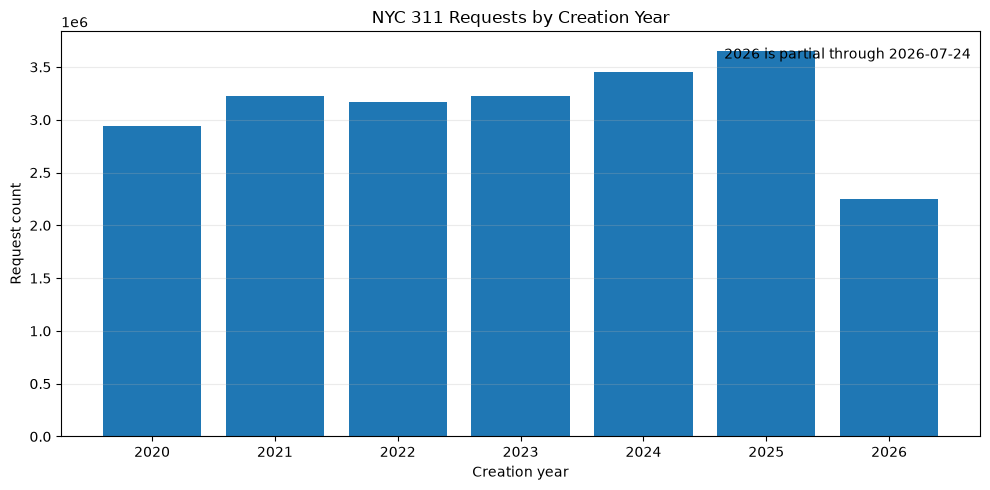

,created_year,record_count,record_percentage
0,2020,2942024,13.420234
1,2021,3220882,14.692262
2,2022,3169960,14.459978
3,2023,3224723,14.709783
4,2024,3456770,15.768281
5,2025,3655037,16.672689
6,2026,2252905,10.276772


In [15]:
records_by_year = pd.DataFrame(fetch_api_records(year_query))
records_by_year["creation_year"] = pd.to_numeric(
    records_by_year["creation_year"],
    errors="raise",
).astype("int64")
records_by_year["record_count"] = pd.to_numeric(
    records_by_year["record_count"],
    errors="raise",
).astype("int64")
records_by_year = records_by_year.rename(
    columns={"creation_year": "created_year"}
)
records_by_year["record_percentage"] = (
    records_by_year["record_count"] / total_row_count * 100
)
records_by_year.to_csv(
    REPORT_TABLES_DIR / "records_by_year.csv",
    index=False,
)

latest_year_is_partial = maximum_created_date < pd.Timestamp(
    year=maximum_created_date.year,
    month=12,
    day=31,
    hour=23,
    minute=59,
    second=59,
)

figure, axis = plt.subplots(figsize=(10, 5))
axis.bar(
    records_by_year["created_year"].astype(str),
    records_by_year["record_count"],
)
axis.set_title("NYC 311 Requests by Creation Year")
axis.set_xlabel("Creation year")
axis.set_ylabel("Request count")
axis.grid(axis="y", alpha=0.25)
if latest_year_is_partial:
    axis.text(
        0.99,
        0.96,
        (
            f"{maximum_created_date.year} is partial through "
            f"{maximum_created_date.date().isoformat()}"
        ),
        transform=axis.transAxes,
        ha="right",
        va="top",
    )
figure.tight_layout()
figure.savefig(
    REPORT_FIGURES_DIR / "records_by_year.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

records_by_year

## 13. Monthly request volume

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

The chart is descriptive only; no anomaly detection is performed. The
complete monthly table behind the chart is saved for reproducibility.

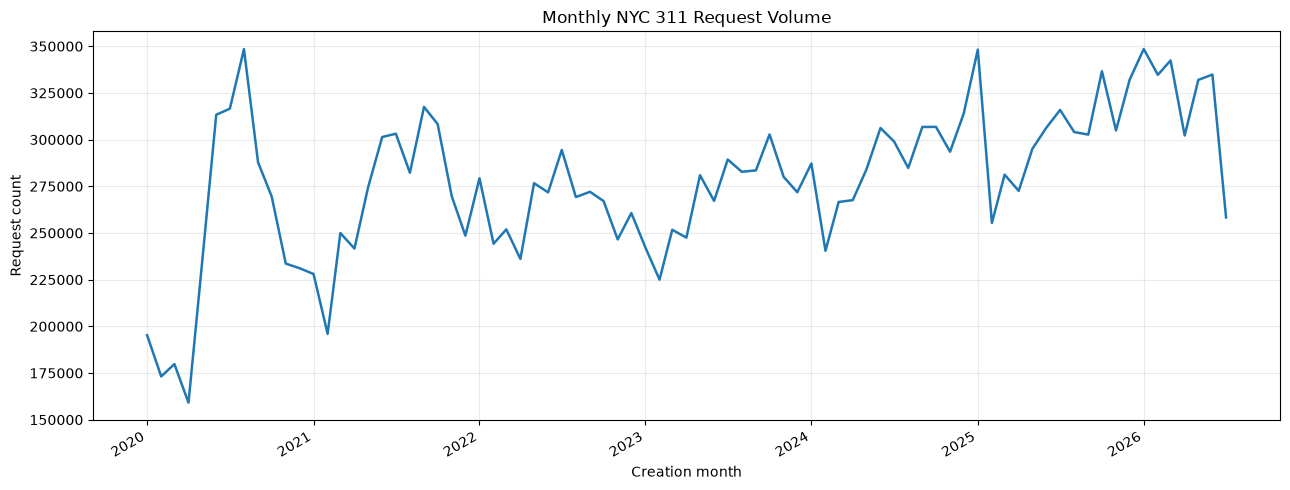

,created_month,record_count
67,2025-08-01,304038
68,2025-09-01,302684
69,2025-10-01,336612
70,2025-11-01,304905
71,2025-12-01,332105
72,2026-01-01,348511
73,2026-02-01,334691
74,2026-03-01,342388
75,2026-04-01,302189
76,2026-05-01,331976


In [16]:
records_by_month = pd.DataFrame(fetch_api_records(month_query))
records_by_month["creation_month"] = pd.to_datetime(
    records_by_month["creation_month"],
    errors="raise",
)
records_by_month["record_count"] = pd.to_numeric(
    records_by_month["record_count"],
    errors="raise",
).astype("int64")
records_by_month = records_by_month.rename(
    columns={"creation_month": "created_month"}
)
records_by_month.to_csv(
    REPORT_TABLES_DIR / "records_by_month.csv",
    index=False,
)

figure, axis = plt.subplots(figsize=(13, 5))
axis.plot(
    records_by_month["created_month"],
    records_by_month["record_count"],
    linewidth=1.8,
)
axis.set_title("Monthly NYC 311 Request Volume")
axis.set_xlabel("Creation month")
axis.set_ylabel("Request count")
axis.grid(alpha=0.25)
figure.autofmt_xdate()
figure.tight_layout()
figure.savefig(
    REPORT_FIGURES_DIR / "records_over_time.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

records_by_month.tail(12)

## 14. Agency analysis

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

The complete agency distribution is saved. A concise count and the twenty
largest agency groups are displayed to keep the notebook readable.

In [17]:
agency_summary = fetch_group_summary(
    group_query_columns["agency_summary"],
    ["Agency", "Agency Name"],
    total_row_count,
)
agency_summary.to_csv(
    REPORT_TABLES_DIR / "agency_summary.csv",
    index=False,
)

agency_codes = agency_summary["Agency"].drop_duplicates().astype(str).tolist()
display(
    Markdown(
        f"The live dataset contains **{len(agency_codes):,} agency codes**. "
        "The top 20 agency groups are displayed below; the complete "
        "distribution is saved to "
        "`reports/01_data_overview/tables/agency_summary.csv`."
    )
)
agency_summary.head(20)

The live dataset contains **21 agency codes**. The top 20 agency groups are displayed below; the complete distribution is saved to `reports/01_data_overview/tables/agency_summary.csv`.

,Agency,Agency Name,record_count,record_percentage
0,NYPD,New York City Police Department,9569537,43.652065
1,HPD,Department of Housing Preservation and Development,4354493,19.863303
2,DSNY,Department of Sanitation,2469736,11.265861
3,DOT,Department of Transportation,1469836,6.704752
4,DEP,Department of Environmental Protection,1162645,5.303481
5,DPR,Department of Parks and Recreation,827149,3.773094
6,DOB,Department of Buildings,639977,2.919297
7,DOHMH,Department of Health and Mental Hygiene,528276,2.409765
8,DHS,Department of Homeless Services,288678,1.316823
9,TLC,Taxi and Limousine Commission,196782,0.897634


## 15. Complaint-category analysis

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

The complete category distribution is saved. The category count and top
twenty rows are displayed instead of producing one oversized value list.

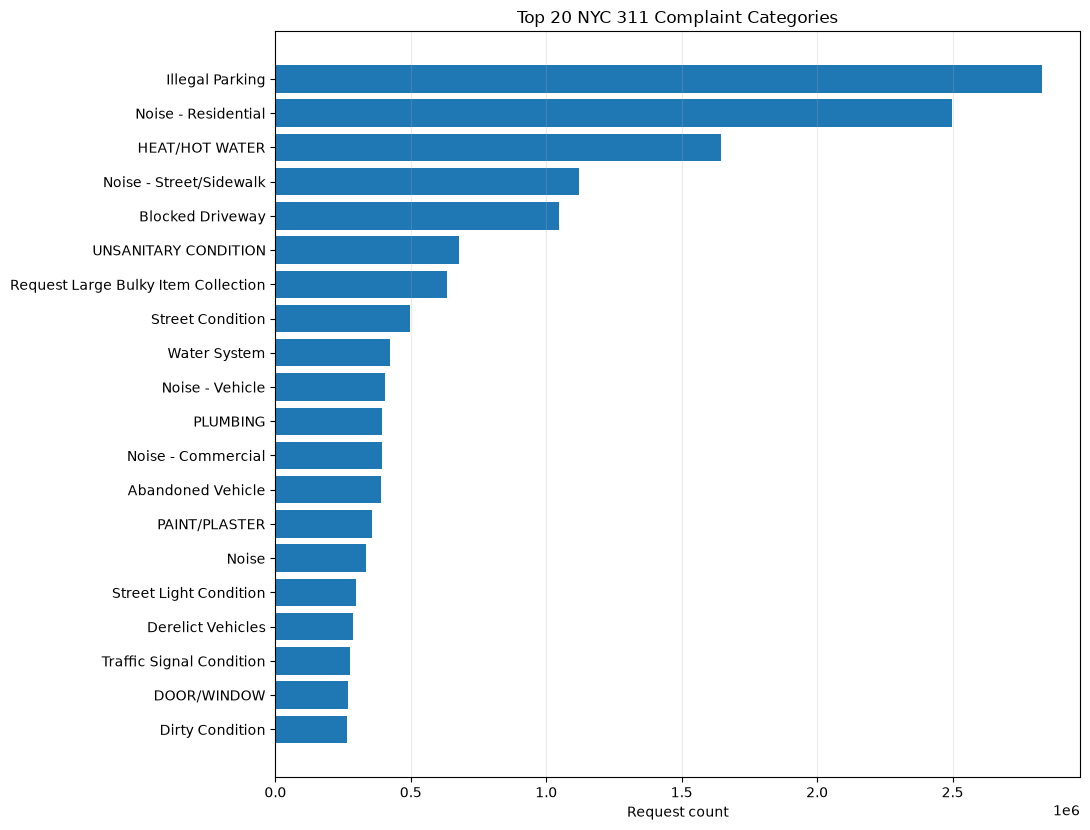

The live dataset contains **272 complaint categories**. The top 20 are displayed below; the complete distribution is saved to `reports/01_data_overview/tables/complaint_type_summary.csv`.

,complaint_type,record_count,record_percentage
0,Illegal Parking,2829028,12.904795
1,Noise - Residential,2498692,11.397946
2,HEAT/HOT WATER,1645147,7.504445
3,Noise - Street/Sidewalk,1122003,5.118090
4,Blocked Driveway,1046677,4.774485
5,UNSANITARY CONDITION,679291,3.098630
6,Request Large Bulky Item Collection,632148,2.883584
7,Street Condition,497404,2.268941
8,Water System,423496,1.931805
9,Noise - Vehicle,403388,1.840081


In [18]:
complaint_type_summary = fetch_group_summary(
    group_query_columns["complaint_type_summary"],
    ["complaint_type"],
    total_row_count,
)
complaint_type_summary.to_csv(
    REPORT_TABLES_DIR / "complaint_type_summary.csv",
    index=False,
)
save_horizontal_bar_chart(
    complaint_type_summary,
    "complaint_type",
    "Top 20 NYC 311 Complaint Categories",
    REPORT_FIGURES_DIR / "records_by_complaint_type.png",
    top_n=20,
)

complaint_categories = (
    complaint_type_summary["complaint_type"].astype(str).tolist()
)
display(
    Markdown(
        f"The live dataset contains **{len(complaint_categories):,} "
        "complaint categories**. The top 20 are displayed below; the "
        "complete distribution is saved to "
        "`reports/01_data_overview/tables/complaint_type_summary.csv`."
    )
)
complaint_type_summary.head(20)

## 16. Descriptor analysis

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

The complete descriptor and complaint-type/descriptor distributions are
saved. Only the top twenty descriptors are displayed and the top fifteen are
plotted.

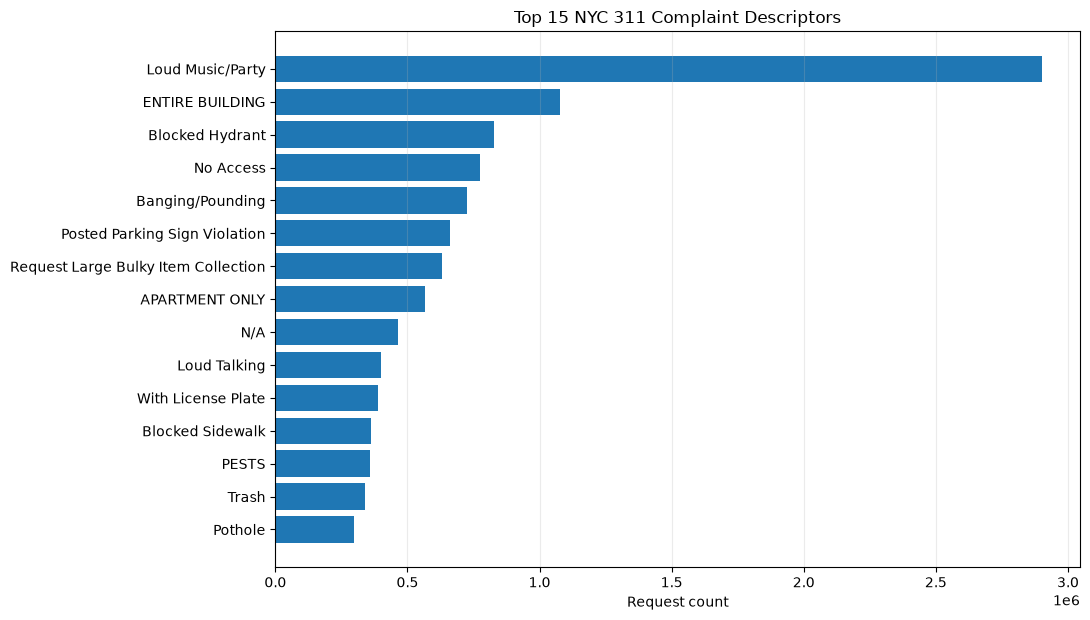

The live dataset contains **1,295 descriptor groups**, including the explicit missing group when present. The complete distribution is saved to `reports/01_data_overview/tables/descriptor_summary.csv`.

,descriptor,record_count,record_percentage
0,Loud Music/Party,2900569,13.231134
1,ENTIRE BUILDING,1078151,4.918056
2,Blocked Hydrant,829058,3.781802
3,No Access,775670,3.538269
4,Banging/Pounding,724015,3.302641
5,Posted Parking Sign Violation,662918,3.023944
6,Request Large Bulky Item Collection,632148,2.883584
7,APARTMENT ONLY,566996,2.586389
8,N/A,465942,2.125425
9,Loud Talking,401481,1.831382


In [19]:
descriptor_summary = fetch_group_summary(
    group_query_columns["descriptor_summary"],
    ["descriptor"],
    total_row_count,
)
descriptor_summary.to_csv(
    REPORT_TABLES_DIR / "descriptor_summary.csv",
    index=False,
)
save_horizontal_bar_chart(
    descriptor_summary,
    "descriptor",
    "Top 15 NYC 311 Complaint Descriptors",
    REPORT_FIGURES_DIR / "top_complaint_descriptors.png",
    top_n=15,
)

complaint_type_descriptor_summary = fetch_group_summary(
    group_query_columns["complaint_type_descriptor_summary"],
    ["complaint_type", "descriptor"],
    total_row_count,
).drop(columns="record_percentage")
complaint_type_descriptor_summary.to_csv(
    REPORT_TABLES_DIR / "complaint_type_descriptor_summary.csv",
    index=False,
)

display(
    Markdown(
        f"The live dataset contains **{len(descriptor_summary):,} descriptor "
        "groups**, including the explicit missing group when present. The "
        "complete distribution is saved to "
        "`reports/01_data_overview/tables/descriptor_summary.csv`."
    )
)
descriptor_summary.head(20)

## 17. Status analysis

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

No status is excluded. Unresolved workflow states may require special
treatment during later target-feasibility analysis.

In [20]:
status_summary = fetch_group_summary(
    group_query_columns["status_summary"],
    ["status"],
    total_row_count,
)
status_summary.to_csv(
    REPORT_TABLES_DIR / "status_summary.csv",
    index=False,
)
status_summary

,status,record_count,record_percentage
0,Closed,21482102,97.992004
1,In Progress,260900,1.190112
2,Open,82747,0.377456
3,Pending,62962,0.287205
4,Assigned,24714,0.112735
5,Started,6093,0.027794
6,Unspecified,2782,0.012690
7,Cancel,1,0.000005


## 18. Borough analysis

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

Missing groups remain explicit. No borough values are repaired or
standardized.

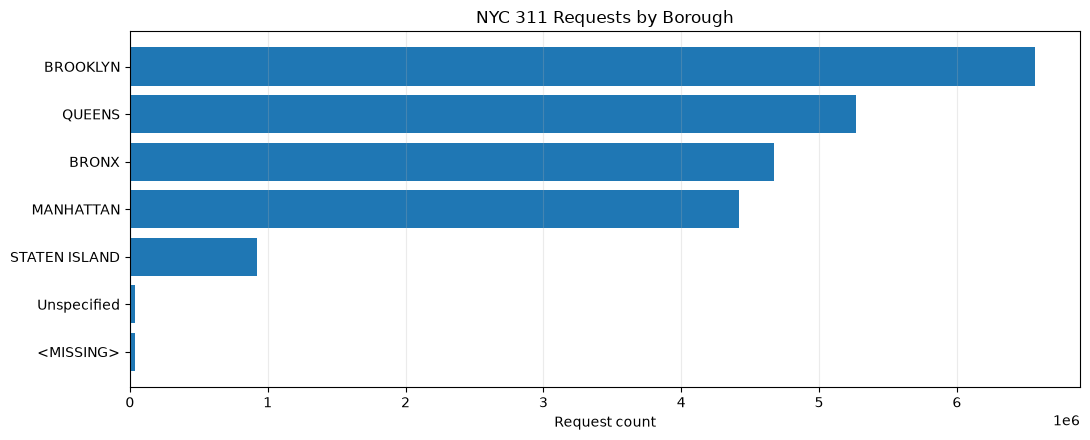

,borough,record_count,record_percentage
0,BROOKLYN,6564915,29.946286
1,QUEENS,5265017,24.016717
2,BRONX,4675320,21.326776
3,MANHATTAN,4415925,20.143529
4,STATEN ISLAND,922648,4.208719
5,Unspecified,40043,0.182659
6,<MISSING>,38433,0.175315


In [21]:
borough_summary = fetch_group_summary(
    group_query_columns["borough_summary"],
    ["borough"],
    total_row_count,
)
borough_summary.to_csv(
    REPORT_TABLES_DIR / "borough_summary.csv",
    index=False,
)
save_horizontal_bar_chart(
    borough_summary,
    "borough",
    "NYC 311 Requests by Borough",
    REPORT_FIGURES_DIR / "records_by_borough.png",
)

borough_summary

## 19. Intake-channel analysis

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

Values are reported exactly as found, with missing records labelled
explicitly.

In [22]:
channel_summary = fetch_group_summary(
    group_query_columns["channel_summary"],
    ["open_data_channel_type"],
    total_row_count,
)
channel_summary.to_csv(
    REPORT_TABLES_DIR / "channel_summary.csv",
    index=False,
)
channel_summary

,open_data_channel_type,record_count,record_percentage
0,ONLINE,9044837,41.258611
1,PHONE,6594073,30.079292
2,MOBILE,4395777,20.051622
3,UNKNOWN,1886238,8.604197
4,OTHER,1376,0.006277


## 20. Location-type analysis

> **Analysis scope:** This section uses a server-side aggregation over the
> complete live NYC 311 API dataset.

The complete location-type summary is saved. Only the top twenty values are
displayed to keep notebook output readable.

In [23]:
location_type_summary = fetch_group_summary(
    group_query_columns["location_type_summary"],
    ["location_type"],
    total_row_count,
)
location_type_summary.to_csv(
    REPORT_TABLES_DIR / "location_type_summary.csv",
    index=False,
)
location_type_summary.head(20)

,location_type,record_count,record_percentage
0,Street/Sidewalk,6234229,28.437841
1,RESIDENTIAL BUILDING,4340880,19.801206
2,<MISSING>,2913577,13.290471
3,Residential Building/House,2680984,12.229483
4,Street,1990771,9.081031
5,Sidewalk,1600893,7.302577
6,Store/Commercial,409277,1.866944
7,Park,190574,0.869316
8,Above Address,176600,0.805572
9,Club/Bar/Restaurant,173551,0.791664


## 21. Sample completeness and distinct-value inspection

> **Analysis scope:** This section uses the deterministic row-level sample,
> not the complete dataset.

These figures describe only the downloaded sample. They must not be treated
as population-wide missingness, distinct-value counts, or production
data-quality rates. The table does not impute, drop, quarantine, or define
quality thresholds.

In [24]:
def count_unique_values(series: pd.Series) -> int:
    """Count distinct sample values, canonicalizing nested JSON structures."""
    hashable_values = series.map(
        lambda value: (
            json.dumps(value, sort_keys=True)
            if isinstance(value, (dict, list))
            else value
        )
    )
    return int(hashable_values.nunique(dropna=True))


sample_column_summary = pd.DataFrame(
    {
        "column_name": df.columns,
        "pandas_dtype": [str(dtype) for dtype in df.dtypes],
        "non_null_count": df.notna().sum().to_numpy(),
        "missing_count": df.isna().sum().to_numpy(),
        "missing_percentage": (df.isna().mean() * 100).to_numpy(),
        "unique_count": [
            count_unique_values(df[column]) for column in df.columns
        ],
        "analysis_scope": "deterministic_row_sample",
    }
).sort_values(
    ["missing_percentage", "column_name"],
    ascending=[False, True],
    ignore_index=True,
)
sample_column_summary.to_csv(
    REPORT_TABLES_DIR / "sample_column_summary.csv",
    index=False,
)
sample_column_summary

,column_name,pandas_dtype,non_null_count,missing_count,missing_percentage,unique_count,analysis_scope
0,due_date,float64,0,7000,100.000000,0,deterministic_row_sample
1,road_ramp,str,3,6997,99.957143,1,deterministic_row_sample
2,taxi_company_borough,str,3,6997,99.957143,2,deterministic_row_sample
3,bridge_highway_direction,str,6,6994,99.914286,6,deterministic_row_sample
4,bridge_highway_name,str,19,6981,99.728571,14,deterministic_row_sample
5,bridge_highway_segment,str,19,6981,99.728571,7,deterministic_row_sample
6,taxi_pick_up_location,str,31,6969,99.557143,27,deterministic_row_sample
7,vehicle_type,str,93,6907,98.671429,5,deterministic_row_sample
8,facility_type,str,102,6898,98.542857,2,deterministic_row_sample
9,descriptor_2,str,677,6323,90.328571,123,deterministic_row_sample


## 22. Day 2 question-and-answer summary

The answers below are assembled from computed full-dataset aggregates,
configured API fields, and explicitly labelled sample observations. Long
categorical distributions remain in their saved tables.

In [25]:
status_values = status_summary["status"].astype(str).tolist()
borough_values = borough_summary["borough"].astype(str).tolist()
channel_values = channel_summary["open_data_channel_type"].astype(str).tolist()


def concise_value_answer(
    values: list[str],
    output_filename: str,
    maximum_display_values: int = 12,
) -> str:
    """Return a readable value list or a pointer to its complete table."""
    if len(values) <= maximum_display_values:
        return ", ".join(values)
    return (
        f"{len(values):,} values; see {output_filename} for the complete list."
    )


is_broad_source = (
    len(agency_codes) > 1 and len(complaint_categories) > 1
)
source_scope_answer = (
    "Broad: multiple agencies and complaint categories are present; "
    "a narrower modelling scope will be selected later."
    if is_broad_source
    else "Narrow based on the currently observed agency and category counts."
)
latest_year_answer = (
    f"No; {maximum_created_date.year} is partial through "
    f"{maximum_created_date.date().isoformat()}."
    if latest_year_is_partial
    else f"Yes; {maximum_created_date.year} appears complete through year end."
)

day_2_summary = pd.DataFrame(
    [
        {
            "question": "How many columns are available?",
            "answer": (
                f"{len(SELECTED_COLUMNS):,} selected API columns were "
                "successfully queried; see column_inventory.csv."
            ),
            "analysis_scope": "configured_live_api_projection",
        },
        {
            "question": "How many total records are present?",
            "answer": f"{total_row_count:,} records.",
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "What date range is covered?",
            "answer": (
                f"{minimum_created_date.date().isoformat()} through "
                f"{maximum_created_date.date().isoformat()}."
            ),
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "How many agencies occur?",
            "answer": (
                f"{len(agency_codes):,} agency codes; see "
                "agency_summary.csv for the complete distribution."
            ),
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "How many complaint categories occur?",
            "answer": (
                f"{len(complaint_categories):,} categories; see "
                "complaint_type_summary.csv for the complete distribution."
            ),
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "How many descriptor values occur?",
            "answer": (
                f"{len(descriptor_summary):,} descriptor groups; see "
                "descriptor_summary.csv for the complete distribution."
            ),
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "Which statuses occur?",
            "answer": concise_value_answer(
                status_values,
                "status_summary.csv",
            ),
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "Which borough values occur?",
            "answer": concise_value_answer(
                borough_values,
                "borough_summary.csv",
            ),
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "Which intake channels occur?",
            "answer": concise_value_answer(
                channel_values,
                "channel_summary.csv",
            ),
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "Is the latest year complete?",
            "answer": latest_year_answer,
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "Is the source broad or narrowly scoped?",
            "answer": source_scope_answer,
            "analysis_scope": "full_dataset_api_aggregation",
        },
        {
            "question": "What should be investigated next?",
            "answer": (
                "Required fields, identifiers, missingness, timestamp "
                "validity, and schema drift in "
                "02_schema_and_quality_analysis.ipynb."
            ),
            "analysis_scope": "workflow_conclusion",
        },
    ]
)
day_2_summary.to_csv(
    REPORT_TABLES_DIR / "day_2_summary.csv",
    index=False,
)

display(
    Markdown(
        "### Computed conclusion\n\n"
        f"The live endpoint is a **{'broad' if is_broad_source else 'narrow'} "
        "NYC 311 source** based on the computed agency and complaint-category "
        "counts. A narrower modelling scope will be selected during a later "
        "scope-selection stage."
    )
)
day_2_summary

### Computed conclusion

The live endpoint is a **broad NYC 311 source** based on the computed agency and complaint-category counts. A narrower modelling scope will be selected during a later scope-selection stage.

,question,answer,analysis_scope
0,How many columns are available?,44 selected API columns were successfully queried; see column_inventory.csv.,configured_live_api_projection
1,How many total records are present?,"21,922,301 records.",full_dataset_api_aggregation
2,What date range is covered?,2020-01-01 through 2026-07-24.,full_dataset_api_aggregation
3,How many agencies occur?,21 agency codes; see agency_summary.csv for the complete distribution.,full_dataset_api_aggregation
4,How many complaint categories occur?,272 categories; see complaint_type_summary.csv for the complete distribution.,full_dataset_api_aggregation
5,How many descriptor values occur?,"1,295 descriptor groups; see descriptor_summary.csv for the complete distribution.",full_dataset_api_aggregation
6,Which statuses occur?,"Closed, In Progress, Open, Pending, Assigned, Started, Unspecified, Cancel",full_dataset_api_aggregation
7,Which borough values occur?,"BROOKLYN, QUEENS, BRONX, MANHATTAN, STATEN ISLAND, Unspecified, <MISSING>",full_dataset_api_aggregation
8,Which intake channels occur?,"ONLINE, PHONE, MOBILE, UNKNOWN, OTHER",full_dataset_api_aggregation
9,Is the latest year complete?,No; 2026 is partial through 2026-07-24.,full_dataset_api_aggregation


## Day 2 completion status

This notebook fulfills the Day 2 data-overview objective by documenting the
live NYC 311 API source's:

- selected available columns;
- total dataset size;
- creation-date coverage;
- agencies;
- complaint categories;
- descriptors;
- statuses;
- boroughs;
- intake channels;
- location types;
- yearly and monthly volume;
- initial row-level pandas data types;
- high-level sample completeness and distinct-value observations.

Full-dataset server-side aggregations are clearly separated from observations
based on the deterministic row-level sample.

No cleaning, row removal, imputation, target creation, final feature
selection, splitting, modelling, or production ingestion was performed.

The next step is:

`notebooks/02_schema_and_quality_analysis.ipynb`